In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import torch

from datasets import load_dataset
from scripts.data_visualization import overlay_masks
from scripts.model_helper import load_model,run_sam3

device = "cuda" if torch.cuda.is_available() else "cpu"

SA1B_DIR = Path('../data/sa1b')


In [ ]:
ds = load_dataset('facebook/SACo-Gold', 'SA-1B')
ds=ds['test']
print('Columns:', ds.column_names)
print('First row:')
row = ds[0]
for k, v in row.items():
    print(f'  {k!r:25s} {type(v).__name__:12s}  {str(v)[:80]}')

'[Errno 101] Network is unreachable' thrown while requesting HEAD https://huggingface.co/datasets/facebook/SACo-Gold/resolve/4c3fefec0bf7549dd04fd83f0ac00f6f26b750f1/SACo-Gold.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since facebook/SACo-Gold couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'SA-1B' at /home/yarra/.cache/huggingface/datasets/facebook___sa_co-gold/SA-1B/0.0.0/4c3fefec0bf7549dd04fd83f0ac00f6f26b750f1 (last modified on Fri May  8 18:09:40 2026).


Columns: ['info', 'images', 'annotations', 'categories', 'licenses']
First row:
  'info'                    dict          {'version': 'v1', 'date': datetime.datetime(2025, 10, 3, 0, 0), 'description': '
  'images'                  list          [{'id': 10000000, 'file_name': 'sa_429746.jpg', 'text_input': 'people', 'width':
  'annotations'             list          [{'area': 0.005675851851851852, 'id': 1, 'image_id': 10000000, 'frame_index': -1
  'categories'              list          [{'supercategory': 'object', 'id': 1, 'name': 'object'}]
  'licenses'                list          []


In [ ]:
def hex_rgb(h):
    h = h.lstrip('#')
    return int(h[0:2],16), int(h[2:4],16), int(h[4:6],16)

def decode_rle(rle):
    h, w = rle['size']
    try:
        from pycocotools import mask as M
        return M.decode(rle).astype(bool)
    except ImportError:
        flat = np.zeros(h * w, dtype=bool)
        idx = 0
        for i, cnt in enumerate(rle['counts']):
            if i % 2 == 1:
                flat[idx:idx+cnt] = True
            idx += cnt
        return flat.reshape((h, w), order='F')

Collected 6 samples


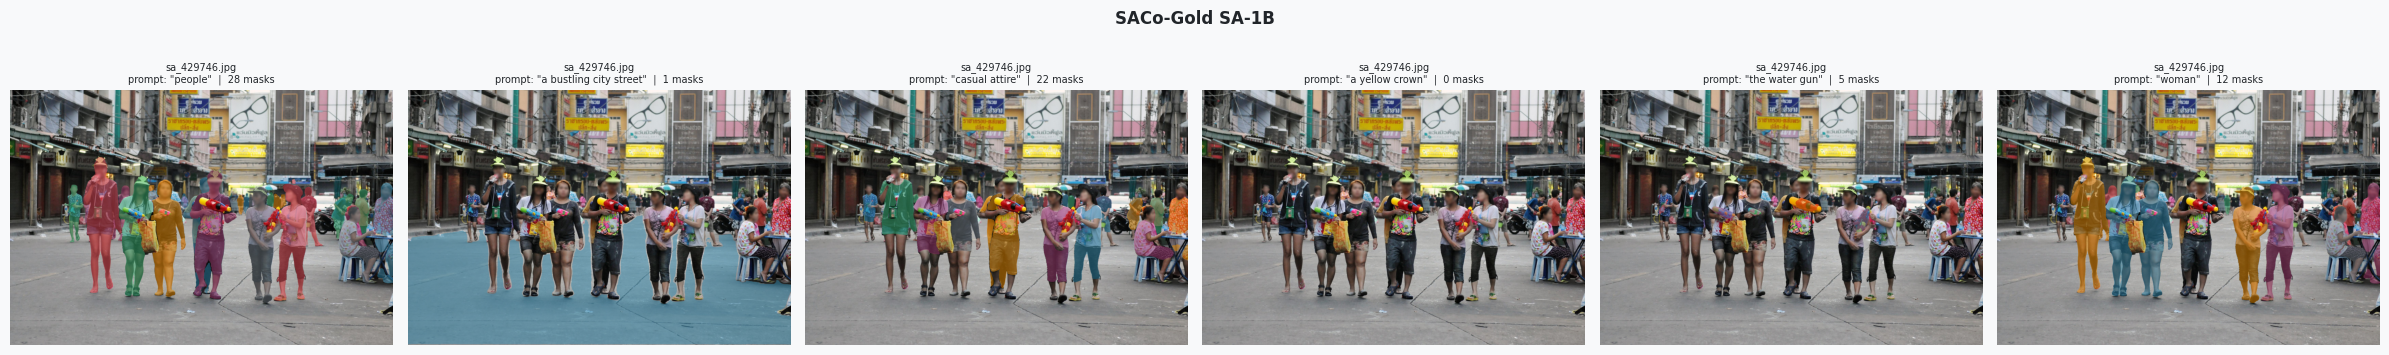

In [ ]:
samples = []

for row in ds:
    ann_by_image = {}
    for ann in row.get('annotations', []):
        ann_by_image.setdefault(ann['image_id'], []).append(ann)

    for img_info in row.get('images', []):
        fname    = img_info['file_name']
        img_path = SA1B_DIR / fname
        if not img_path.exists():
            continue

        img_arr = np.array(Image.open(img_path).convert('RGB'))
        anns    = ann_by_image.get(img_info['id'], [])
        masks   = []
        for ann in anns:
            seg = ann.get('segmentation')
            if seg:
                try:
                    masks.append(decode_rle(seg))
                except Exception:
                    pass

        samples.append((img_arr, fname, img_info.get('text_input', ''), masks))
        if len(samples) >= 6:
            break
    if len(samples) >= 6:
        break

print(f'Collected {len(samples)} samples')

n   = len(samples)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4), facecolor=C2A['bg'])
if n == 1:
    axes = [axes]

for ax, (img, fname, text, masks) in zip(axes, samples):
    ax.imshow(overlay_masks(img, masks))
    ax.set_title(f'{fname}\nprompt: "{text}"  |  {len(masks)} masks',
                 fontsize=7)
    ax.axis('off')

fig.suptitle('SACo-Gold SA-1B', fontweight='bold')
plt.tight_layout()
plt.show()


In [6]:
model,processor = load_model(device)

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Ran sam3 inference
Collected 2 samples


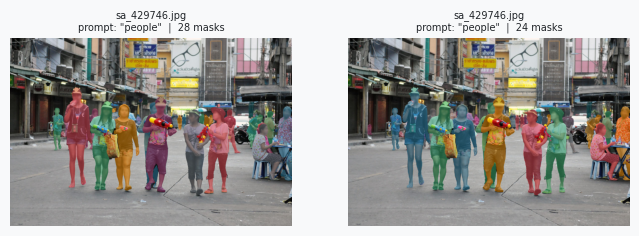

In [ ]:
samples = []
for row in ds:
    # each row is a COCO-style chunk: images[] + annotations[]
    ann_by_image = {}
    for ann in row.get('annotations', []):
        ann_by_image.setdefault(ann['image_id'], []).append(ann)

    for img_info in row.get('images', []):
        fname    = img_info['file_name']
        img_path = SA1B_DIR / fname
        if not img_path.exists():
            continue

        
        img_arr = np.array(Image.open(img_path).convert('RGB'))
        results = run_sam3(model,processor,img_arr,device,img_info.get('text_input', ''))
        print("Ran sam3 inference")
        anns    = ann_by_image.get(img_info['id'], [])
        masks   = []
        for ann in anns:
            seg = ann.get('segmentation')
            if seg:
                try:
                    masks.append(decode_rle(seg))
                except Exception:
                    pass

        samples.append((img_arr, fname, img_info.get('text_input', ''), masks))
        samples.append((img_arr, fname, img_info.get('text_input', ''), results["masks"].cpu().numpy()))
        if len(samples) >= 1:
            break
    if len(samples) >= 1:
        break

print(f'Collected {len(samples)} samples')

# -- plot -----------------------------------------------------------------
n   = len(samples)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4), facecolor=C2A['bg'])
if n == 1:
    axes = [axes]

for ax, (img, fname, text, masks) in zip(axes, samples):
    ax.imshow(overlay_masks(img, masks))
    ax.set_title(f'{fname}\nprompt: "{text}"  |  {len(masks)} masks',
                 color=C2A['text'], fontsize=7)
    ax.axis('off')